# Preparing data to be used in models trainings

# Sorghum

## For Segmentation

In [22]:
import os
import cv2
from tqdm import tqdm

ROOT_DIR = "data/yolo_segmentation"
OUTPUT_DIR = "data/yolo_cropped"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def convert_to_absolute(coords, width, height):
    """Convert relative YOLO coordinates to absolute pixel coordinates"""
    absolute_coords = []
    for i in range(0, len(coords), 2):
        x = float(coords[i]) * width
        y = float(coords[i + 1]) * height
        absolute_coords.append((x, y))
    return absolute_coords

def convert_to_relative(points, width, height):
    """Convert absolute coordinates to relative YOLO format"""
    relative_coords = []
    for x, y in points:
        relative_coords.append(x / width)
        relative_coords.append(y / height)
    return relative_coords

def process_image(img_path, label_path, output_img_path, output_label_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read image: {img_path}")
        return
    
    h, w = img.shape[:2]

    with open(label_path, 'r') as f:
        lines = f.readlines()

    # Find bounding box for all objects in the image
    all_xs = []
    all_ys = []
    
    for line in lines:
        parts = line.strip().split()
        cls = parts[0]
        coords = convert_to_absolute(parts[1:], w, h)
        xs, ys = zip(*coords)
        all_xs.extend(xs)
        all_ys.extend(ys)
    
    # If no coordinates were found
    if not all_xs or not all_ys:
        print(f"No valid coordinates found in {label_path}")
        return
    
    # Calculate the expanded bounding box
    xmin = max(int(min(all_xs)) - 20, 0)
    ymin = max(int(min(all_ys)) - 20, 0)
    xmax = min(int(max(all_xs)) + 20, w)
    ymax = min(int(max(all_ys)) + 20, h)
    
    # Crop image
    cropped = img[ymin:ymax, xmin:xmax]
    crop_h, crop_w = cropped.shape[:2]
    
    # Resize to 640x640
    cropped_resized = cv2.resize(cropped, (640, 640))
    cv2.imwrite(output_img_path, cropped_resized)
    
    # Process all annotation lines
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        cls = parts[0]
        coords = convert_to_absolute(parts[1:], w, h)
        
        # Adjust coordinates to cropped region
        adjusted_coords = [(x - xmin, y - ymin) for x, y in coords]
        
        # Scale to 640x640
        scale_x = 640.0 / crop_w
        scale_y = 640.0 / crop_h
        scaled_coords = [(x * scale_x, y * scale_y) for x, y in adjusted_coords]
        
        # Convert back to relative coordinates
        relative_coords = convert_to_relative(scaled_coords, 640, 640)
        
        # Ensure coordinates are within [0, 1]
        relative_coords = [max(0, min(1, coord)) for coord in relative_coords]
        
        # Format line
        new_line = f"{cls} " + " ".join([f"{c:.6f}" for c in relative_coords]) + "\n"
        new_lines.append(new_line)
    
    # Write new labels
    with open(output_label_path, 'w') as f:
        f.writelines(new_lines)
    
    print(f"Processed: {os.path.basename(img_path)}")

# Iterate through subfolders
for subfolder in tqdm(os.listdir(ROOT_DIR),"Cropping and resizing images and labels"):
    sub_path = os.path.join(ROOT_DIR, subfolder)
    if not os.path.isdir(sub_path):
        continue

    img_folder = os.path.join(sub_path, "images")
    lbl_folder = os.path.join(sub_path, "labels")
    
    if not os.path.exists(img_folder) or not os.path.exists(lbl_folder):
        print(f"Skipping {subfolder}: missing images or labels folder")
        continue

    out_img_folder = os.path.join(OUTPUT_DIR, subfolder, "images")
    out_lbl_folder = os.path.join(OUTPUT_DIR, subfolder, "labels")
    os.makedirs(out_img_folder, exist_ok=True)
    os.makedirs(out_lbl_folder, exist_ok=True)

    print(f"Processing subfolder: {subfolder}")
    for img_file in os.listdir(img_folder):
        if img_file.endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(img_folder, img_file)
            label_file = os.path.splitext(img_file)[0] + ".txt"
            label_path = os.path.join(lbl_folder, label_file)

            if os.path.exists(label_path):
                output_img_path = os.path.join(out_img_folder, img_file)
                output_label_path = os.path.join(out_lbl_folder, label_file)
                process_image(img_path, label_path, output_img_path, output_label_path)
            else:
                print(f"No label found for {img_file}")
    print(f"Completed processing {subfolder}")

print("Processing complete!")

Processing subfolder: test
Processed: 0299653b-689e-413d-b255-1d84cc9f7590_JPG.rf.63fe071ec8cb224f34f28e79644ce254.jpg
Processed: 090450_jpg.rf.bc94850c9341d7cd4f2d8d534c96d0ae.jpg
Processed: 090502_jpg.rf.47900c244f65f3b4d6e72a77ac1c3da1.jpg
Processed: 090513_jpg.rf.2897f5e21a46a5eae5a67231dc7d87a2.jpg
Processed: 090532_jpg.rf.a132e0c302e67f6791db137494cf25f6.jpg
Processed: 090551_jpg.rf.2fde969bdf3b513f1862430ed5d2232a.jpg
Processed: 090645_jpg.rf.bdd561d5242c12300de5a3269ccdea49.jpg
Processed: 090752_jpg.rf.8915bf24c2d24b6eecbf6eaeb238d056.jpg
Processed: 090819_jpg.rf.72df82365250b425dcf052138102f4b4.jpg
Processed: 090849_jpg.rf.e472b719f82bbe720d2968a32d6ab567.jpg
Processed: 090924_jpg.rf.3f1d02f6ba5c1d8c1f51fcb0218ee6d6.jpg
Processed: 091105_jpg.rf.0acb47eb2e42f456ddb0e822a0b2e64a.jpg
Processed: 091249_jpg.rf.fdc1f49f8efc35b2ce4ca7d0b9eef40b.jpg
Processed: 091259_jpg.rf.4e1ac239427befac30e49ca1f45a77e5.jpg
Processed: 091329_jpg.rf.adbf6d509e56b94930951b600b0b670d.jpg
Processed: 09

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def show_image_with_polygon(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib
    h, w = img.shape[:2]

    fig, ax = plt.subplots()
    ax.imshow(img)

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        coords = [float(p) for p in parts[1:]]
        points = [(coords[i] * 640, coords[i + 1] * 640) for i in range(0, len(coords), 2)]

        polygon = Polygon(points, closed=True, fill=True, edgecolor='red', facecolor='red', alpha=0.4)
        ax.add_patch(polygon)

    ax.set_title("Image with Polygon Mask")
    plt.axis('off')
    plt.show()

In [ ]:
show_image_with_polygon("data/yolo_cropped/test/images/0299653b-689e-413d-b255-1d84cc9f7590_JPG.rf.63fe071ec8cb224f34f28e79644ce254.jpg",
                        "data/yolo_cropped/test/labels/0299653b-689e-413d-b255-1d84cc9f7590_JPG.rf.63fe071ec8cb224f34f28e79644ce254.txt")

## Classification

### Creating the database

In [7]:
import os
import json
import cv2
import numpy as np
from tqdm import tqdm

input_folder = "./data/initial_counted_sorghum_panicles"
output_folder = "./data/classification_images/Sorghum"

os.makedirs(output_folder, exist_ok=True)

# Iterate through the images and JSON files
for image_file in tqdm(os.listdir(input_folder), "Masking images"):
    if image_file.endswith(".jpg"):
        # Load the image
        image = cv2.imread(os.path.join(input_folder, image_file))
    json_file = os.path.join(input_folder, os.path.splitext(image_file)[0] + ".json")
    # Load points from JSON file
    with open(json_file, 'r') as file:
        data = json.load(file)
        points = data["shapes"][0]['points']

    mask = np.zeros(image.shape[0:2], dtype=np.uint8)
    pontos = np.array([points])
    pontos = pontos.astype(int)
    cv2.fillPoly(mask, pontos, (255))
    res = cv2.bitwise_and(image, image, mask=mask)

    # Create a black background
    dst = np.zeros_like(image)
    dst[mask == 255] = res[mask == 255]

    x_array = []
    y_array = []

    for point in points:
        x, y = point
        x, y = int(x), int(y)
        x_array.append(x)
        y_array.append(y)

    x_max = max(x_array)
    x_min = min(x_array)
    y_max = max(y_array)
    y_min = min(y_array)

    centered_image = dst[y_min:y_max, x_min:x_max]
    cv2.imwrite(os.path.join(output_folder, os.path.splitext(image_file)[0] + ".png"), centered_image)
    
print("-------- Image masking finished --------")

Masking images: 100%|██████████| 396/396 [01:54<00:00,  3.45it/s]

-------- Image masking finished --------


In [ ]:
from PIL import Image
import os

base_folder = "data/classification_images/Sorghum"

# Define the target size
target_size = (224, 224)

# Iterate through the subfolders and resize images
for subfolder in os.listdir(base_folder):
    subfolder_path = os.path.join(base_folder, subfolder)
    if os.path.isdir(subfolder_path):
        for image_file in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, image_file)
            with Image.open(image_path) as img:
                resized_img = img.resize(target_size)
                resized_img.save(image_path)
                print(f"Resized {image_file} in {subfolder}")

### Augmenting the data

In [16]:
# Implementing data augmentation
import os
import cv2
from imgaug import augmenters as iaa
from tqdm import tqdm

# Define the data augmentation parameters using imgaug
augmentation = iaa.Sequential([
    iaa.Multiply((0.7, 1.3)),  # Change brightness
    iaa.AddToHueAndSaturation((-20, 20)),  # Change hue and saturation
    iaa.LinearContrast((0.5, 2.0), per_channel=0.5), #Contrast in images
    iaa.Add((-10, 10), per_channel=0.5), #Add value to each pixel
    iaa.Sometimes(
        0.5,
        iaa.Fliplr(0.5), #Flip images horizontally
    ),
    iaa.Sometimes(
        0.5,
        iaa.Flipud(0.5), #Flip images vertically
    ),
    iaa.Affine(scale=(0.75, 1)), #Zoom in or out
])

def augment_images(input_folder):

    # Loop through each image in the input folder
    for img_name in tqdm(os.listdir(input_folder), "Augmenting images"):
        if "_aug_" in img_name:
            continue
        
        img_path = os.path.join(input_folder, img_name)

        # Read the image
        img = cv2.imread(img_path)

        augmented_images = augmentation(images=[img] * 4)

        for i in range(4):
            # Save the augmented images
            aug_image_file = os.path.splitext(img_name)[0] + f"_aug_{i}.png"
            cv2.imwrite(os.path.join(input_folder, aug_image_file), augmented_images[i])
        
    print(f'------- Augmentation in folder {input_folder} done -------')

In [20]:
# Replace 'input_folder' and 'output_folder' with your actual input and output folder paths
augment_images("data/classification_images/Random/train")

Augmenting images: 100%|██████████| 115/115 [00:07<00:00, 16.29it/s]

------- Augmentation in folder data/classification_images/Random/train done -------


## For Density Maps

### Resizing Images

In [2]:
import cv2
import json
import os

In [3]:
import random

# Define the input and output directories
input_image_dir = "./data/sorghum_images_rectangle"
output_image_dir = "./data/sorghum_images"
input_json_dir = "./data/sorghum_images_rectangle"
output_json_dir = "./data/sorghum_labels"

# Create output directories if they don't exist
os.makedirs(os.path.join(output_image_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(output_image_dir, "test"), exist_ok=True)
os.makedirs(os.path.join(output_json_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(output_json_dir, "test"), exist_ok=True)

# Define the target image size
target_size = (224, 224)

# Get a list of all image files
image_files = [f for f in os.listdir(input_image_dir) if f.endswith(".png")]

# Shuffle the files and split into train and test sets
random.shuffle(image_files)
split_index = int(len(image_files) * 0.75)
train_files = image_files[:split_index]
test_files = image_files[split_index:]

# Function to process and save files
def process_and_save_files(file_list, subset):
    for image_file in file_list:
        # Load the image
        image = cv2.imread(os.path.join(input_image_dir, image_file))

        # Resize the image to the target size
        image_new = cv2.resize(image, target_size)

        # Load the corresponding JSON data
        json_file = os.path.join(input_json_dir, os.path.splitext(image_file)[0] + ".json")
        with open(json_file, "r") as json_data:
            data = json.load(json_data)

        grain_shapes = []
        for shape in data["shapes"]:
            if shape["label"] == "grain":
                grain_shapes.append(shape)

        # Initialize a list to store scaled "grain" shapes for this image
        scaled_grain_shapes = []

        if grain_shapes:
            for grain_shape in grain_shapes:
                points = grain_shape["points"]

                # Scale the coordinates based on the resizing
                scale_factor_x = target_size[0] / image.shape[1]
                scale_factor_y = target_size[1] / image.shape[0]
                scaled_points = []

                for x, y in points:
                    scaled_x = x * scale_factor_x
                    scaled_y = y * scale_factor_y
                    scaled_points.append([scaled_x, scaled_y])

                # Create a copy of the grain shape with scaled points
                scaled_grain_shape = grain_shape.copy()
                scaled_grain_shape["points"] = scaled_points

                scaled_grain_shapes.append(scaled_grain_shape["points"])

        augmented_json = [data.copy() for _ in range(1)]

        for i in range(1):
            # Update the "points" field in each copy of the JSON data
            for j, scaled_grain_shape in enumerate(scaled_grain_shapes):
                augmented_json[i]["shapes"][j]["points"] = scaled_grain_shape

            # Save the augmented JSON data to a new file
            aug_json_file = os.path.splitext(image_file)[0] + f".json"
            with open(os.path.join(output_json_dir, subset, aug_json_file), "w") as output_json_data:
                json.dump(augmented_json[i], output_json_data, indent=2)

            # Save the augmented images
            aug_image_file = os.path.splitext(image_file)[0] + f".png"
            cv2.imwrite(os.path.join(output_image_dir, subset, aug_image_file), image_new)

        print(f'Image {image_file} resized and saved to {subset}')

# Process train and test files
process_and_save_files(train_files, "train")
process_and_save_files(test_files, "test")

print("-------- Image resizing and splitting complete --------")

Image 1_090225.png resized and saved to train
Image 2_090228.png resized and saved to train
Image 1_8_0.png resized and saved to train
Image 1_090338.png resized and saved to train
Image 0_3_2.png resized and saved to train
Image 0_5_3.png resized and saved to train
Image 0_090341.png resized and saved to train
Image 111207.png resized and saved to train
Image 0_090313.png resized and saved to train
Image 0_090431.png resized and saved to train
Image 2_4_6.png resized and saved to train
Image 1_19_0.png resized and saved to train
Image 090652.png resized and saved to train
Image 1_090257.png resized and saved to train
Image 0_30_0.png resized and saved to train
Image 2_090357.png resized and saved to train
Image 1_090435.png resized and saved to train
Image 1_090357.png resized and saved to train
Image 0_090435.png resized and saved to train
Image 2_20_0.png resized and saved to train
Image 0_47_0.png resized and saved to train
Image 0_22_0.png resized and saved to train
Image 0_25_0.p

### Creating density maps

In [5]:
import os
import json
import numpy as np
import cv2
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from PIL import Image

Total of 3 gaussian kernels.
Total generated: 2.9999998046875


True

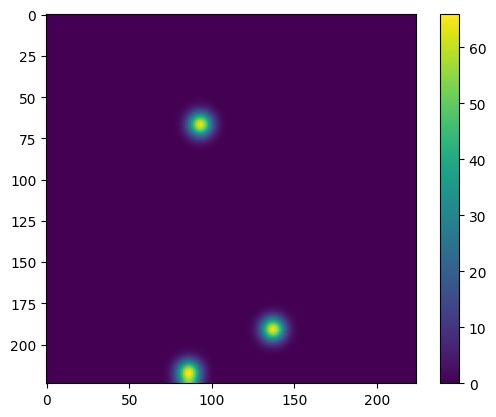

In [37]:
json_path = "data/sorghum_labels/test/0_12_2.json"
scale = 10000

# Load JSON data
with open(json_path, "r") as json_file:
    data = json.load(json_file)
    points = data["shapes"]

img_shape=[224, 224]

# Create an empty density map with the same size as the image
print("Total of", len(points),"gaussian kernels.")
density_map = np.zeros(img_shape, dtype=np.float32)

# Generate density maps based on annotations
for point in points:
    x, y = point["points"][0]
    x, y = int(x), int(y)
    density_map[y, x] += 1

# Normalize the density map to the range 0 to 255
density_map = gaussian_filter(density_map, sigma=5) * scale

# Calculate overall count
overall_count = np.sum(density_map) / scale

print("Total generated:", overall_count)

cmap = 'viridis'
plt.imshow(density_map, cmap=cmap)
plt.colorbar()
plt.show
cv2.imwrite("test.png", density_map)

In [34]:
def create_density_maps(input_folder, output_folder):

    os.makedirs(output_folder, exist_ok=True)
    # Iterate over JSON files in the input folder
    for filename in os.listdir(input_folder):
        if filename.endswith(".json"):
            json_path = os.path.join(input_folder, filename)

            # Load JSON data
            with open(json_path, "r") as json_file:
                data = json.load(json_file)
                points = data["shapes"]

            img_shape=[224, 224]

            # Create an empty density map with the same size as the image
            print("Image name: ",filename,". Totally generated",len(points),"gaussian kernels.")
            density_map = np.zeros(img_shape, dtype=np.float32)

            # Generate density maps based on annotations
            for point in points:
                x, y = point["points"][0]
                x, y = int(x), int(y)
                density_map[y, x] += 1

            density_map = gaussian_filter(density_map, sigma=5) * 10000  # Adjust sigma as needed

            # Save density map as an image
            output_filename = filename.replace(".json", ".png")
            output_path = os.path.join(output_folder, output_filename)
            cv2.imwrite(output_path, density_map)

            print(f'Density map created and saved for {filename}')

    print("----- Density maps generated and saved to the output folder -----")

create_density_maps("./data/sorghum_labels/train", "./data/sorghum_density_maps/train")
create_density_maps("./data/sorghum_labels/test", "./data/sorghum_density_maps/test")

Image name:  090652.json . Totally generated 282 gaussian kernels.
Density map created and saved for 090652.json
Image name:  090652_2.json . Totally generated 438 gaussian kernels.
Density map created and saved for 090652_2.json
Image name:  092006.json . Totally generated 57 gaussian kernels.
Density map created and saved for 092006.json
Image name:  093416.json . Totally generated 189 gaussian kernels.
Density map created and saved for 093416.json
Image name:  093827.json . Totally generated 359 gaussian kernels.
Density map created and saved for 093827.json
Image name:  094416.json . Totally generated 297 gaussian kernels.
Density map created and saved for 094416.json
Image name:  0_090225.json . Totally generated 284 gaussian kernels.
Density map created and saved for 0_090225.json
Image name:  0_090228.json . Totally generated 144 gaussian kernels.
Density map created and saved for 0_090228.json
Image name:  0_090238.json . Totally generated 195 gaussian kernels.
Density map crea

### Verifying the real number

Ground-Truth: 2.9999998046875
Total number of grains: 2.9905


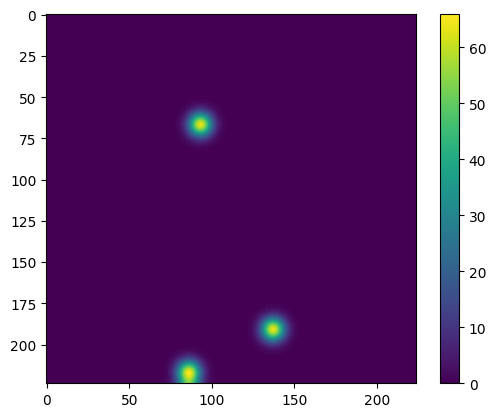

In [36]:
# Load the density map
density_map_path = "./data/sorghum_density_maps/test/0_12_2.png"
density_map = Image.open(density_map_path).convert('L')

with open("data/sorghum_labels/test/0_12_2.json", 'r') as file:
    data = json.load(file)
    points = data["shapes"]

density_map_gt = np.zeros([224,224], dtype=np.float32)

for point in points:
    x, y = point["points"][0]
    x, y = int(x), int(y)
    density_map_gt[y, x] += 1

density_map_gt = gaussian_filter(density_map_gt, sigma=5) * 10000  # Adjust sigma as needed

# Calculate overall count
overall_count = np.sum(density_map_gt) / 10000

total_density = np.sum(density_map) / 10000

cmap = 'viridis'
plt.imshow(density_map, cmap=cmap)
plt.colorbar()
plt.show

print("Ground-Truth:", overall_count)
print("Total number of grains:", total_density)

### Augmenting data

In [38]:
import cv2
import os
import numpy as np
from imgaug import augmenters as iaa

In [39]:
# Define the data augmentation parameters using imgaug
augmentation = iaa.Sequential([
    iaa.Multiply((0.7, 1.3)),  # Change brightness
    iaa.AddToHueAndSaturation((-20, 20)),  # Change hue and saturation
    iaa.LinearContrast((0.5, 2.0), per_channel=0.5), #Contrast in images
    iaa.Add((-10, 10), per_channel=0.5), #Add value to each pixel
    iaa.Sometimes(
        0.5,
        iaa.Fliplr(0.5), #Flip images horizontally
    ),
    iaa.Sometimes(
        0.5,
        iaa.Flipud(0.5), #Flip images vertically
    ),
    iaa.Sometimes(
        0.5,
        iaa.Rot90((1, 3)), #Rotate images by 90, 180, or 270 degrees
    ),
    iaa.Affine(scale=(0.75, 1)), #Zoom in or out
])

def augmenting_data(image_dir, map_dir):
    # Iterate through the images and density maps
    for image_file in os.listdir(image_dir):
        if image_file.endswith(".png"):
            # Load the image
            image = cv2.imread(os.path.join(image_dir, image_file))

            # Load the corresponding density map
            map_file = os.path.join(map_dir, image_file)
            density_map = cv2.imread(map_file, cv2.IMREAD_GRAYSCALE)

            # Convert the 2D density map to a 3D array by adding an extra dimension
            density_map_3d = np.expand_dims(density_map, axis=-1)

            for i in range(10):  # Perform 10 random augmentations for each image
                # Apply the augmentation to the image and density map
                image_aug, density_map_aug = augmentation(image=image, segmentation_maps=[density_map_3d])

                # Save the augmented image
                image_aug_file = os.path.splitext(image_file)[0] + f"_aug_{i}.png"
                cv2.imwrite(os.path.join(image_dir, image_aug_file), image_aug)

                # Save the augmented density map
                map_aug_file = os.path.splitext(image_file)[0] + f"_aug_{i}.png"
                cv2.imwrite(os.path.join(map_dir, map_aug_file), density_map_aug[0])

                print(f'Image {image_file} augmented and saved as {image_aug_file}')

    print("----- Image augmentation complete. -----")

augmenting_data("./data/sorghum_images/train", "./data/sorghum_density_maps/train")
augmenting_data("./data/sorghum_images/test", "./data/sorghum_density_maps/test")

Image 090652.png augmented and saved as 090652_aug_0.png
Image 090652.png augmented and saved as 090652_aug_1.png
Image 090652.png augmented and saved as 090652_aug_2.png
Image 090652.png augmented and saved as 090652_aug_3.png
Image 090652.png augmented and saved as 090652_aug_4.png
Image 090652.png augmented and saved as 090652_aug_5.png
Image 090652.png augmented and saved as 090652_aug_6.png
Image 090652.png augmented and saved as 090652_aug_7.png
Image 090652.png augmented and saved as 090652_aug_8.png
Image 090652.png augmented and saved as 090652_aug_9.png
Image 090652_2.png augmented and saved as 090652_2_aug_0.png
Image 090652_2.png augmented and saved as 090652_2_aug_1.png
Image 090652_2.png augmented and saved as 090652_2_aug_2.png
Image 090652_2.png augmented and saved as 090652_2_aug_3.png
Image 090652_2.png augmented and saved as 090652_2_aug_4.png
Image 090652_2.png augmented and saved as 090652_2_aug_5.png
Image 090652_2.png augmented and saved as 090652_2_aug_6.png
Ima

## For Estimating to the Whole Panicle

### Cropping the images to 3 patches

In [ ]:
import numpy as np
import cv2 
import os
import json

In [ ]:
input_folder = "./data/initial_counted_sorghum_panicles"
output_folder = "./data/counted_images"

os.makedirs(output_folder, exist_ok=True)

# Define the target image size
target_size = (224, 224)

# Iterate through the images and JSON files
for image_file in os.listdir(input_folder):
    if image_file.endswith(".jpg"):
        # Load the image
        image = cv2.imread(os.path.join(input_folder, image_file))

    json_file = os.path.join(input_folder, os.path.splitext(image_file)[0] + ".json")
    # Load points from JSON file
    with open(json_file, 'r') as file:
        data = json.load(file)
        points = data["shapes"][0]['points']

    mask = np.zeros(image.shape[0:2], dtype=np.uint8)
    pontos = np.array([points])
    pontos = pontos.astype(int)
    cv2.fillPoly(mask, pontos, (255))
    res = cv2.bitwise_and(image, image, mask=mask)

    # Create a black background
    dst = np.zeros_like(image)
    dst[mask == 255] = res[mask == 255]

    x_array = []
    y_array = []

    for point in points:
        x, y = point
        x, y = int(x), int(y)
        x_array.append(x)
        y_array.append(y)

    x_max = max(x_array)
    x_min = min(x_array)
    y_max = max(y_array)
    y_min = min(y_array)

    centered_image = dst[y_min:y_max, x_min:x_max]

    height, width = centered_image.shape[:2]
    crop_height = height // 3

    for i in range(3):
            # Calculate the coordinates for cropping
            y1 = i * crop_height
            y2 = (i + 1) * crop_height

            # Crop the region
            cropped_image = centered_image[y1:y2, :]

            # Define the output file name for each cropped image
            cropedImageName = os.path.splitext(image_file)[0]+"_" + str(i) +'.png'
            output_filename = os.path.join(output_folder, f"{cropedImageName}")
            image_new = cv2.resize(cropped_image, target_size)
            # Save the cropped image
            cv2.imwrite(output_filename, image_new)

    print("Cropping", image_file)

print("Cropping finished")